# High-Level Backtesting of the ICT Strategy

In [1]:
# imports
import time
import pandas as pd
from nautilus_trader.backtest.config import BacktestVenueConfig, BacktestDataConfig, BacktestRunConfig
from nautilus_trader.backtest.engine import BacktestResult, BacktestEngine, BacktestEngineConfig
from nautilus_trader.backtest.node import BacktestNode
from nautilus_trader.common.config import LoggingConfig
from nautilus_trader.core.datetime import dt_to_unix_nanos
from nautilus_trader.model import BarType, Bar, Venue, InstrumentId
from nautilus_trader.model.enums import OmsType
from nautilus_trader.persistence.catalog import ParquetDataCatalog
from nautilus_trader.persistence.config import DataCatalogConfig
from nautilus_trader.test_kit.providers import TestInstrumentProvider
from nautilus_trader.trading import trader
from nautilus_trader.trading.config import ImportableStrategyConfig
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [ ]:
from core.enums import MoneyManagementType

catalog = ParquetDataCatalog("../catalog")

#start_ns = dt_to_unix_nanos(pd.Timestamp("2025-01-01"))
start_ns = dt_to_unix_nanos(pd.Timestamp("2025-07-09"))
end_ns = dt_to_unix_nanos(pd.Timestamp("2025-10-22"))

instrument = TestInstrumentProvider.es_future(2025, 12)
instrument_id = instrument.id.value

# Configure backtesting
venue = BacktestVenueConfig(
    name="GLBX",
    oms_type=OmsType.NETTING,
    account_type="MARGIN",
    base_currency="USD",
    starting_balances=["30_000 USD"],
)

# Configure a catalog for a live system
catalog_cfg = DataCatalogConfig(
    path=str(catalog.path),
    fs_protocol="file",
    name="local"
)

base_bar_type = BarType.from_str(f"{instrument_id}-1-MINUTE-LAST-EXTERNAL")
weekly_bar_type = BarType.from_str(f"{instrument_id}-1-WEEK-LAST-INTERNAL@1-MINUTE-EXTERNAL")
daily_bar_type = BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL")

data = BacktestDataConfig(
    catalog_path=str(catalog.path),
    catalog_fs_protocol="file",
    data_cls=Bar,
    bar_types=[base_bar_type],
    instrument_id=instrument_id,
    start_time=start_ns,
    end_time=end_ns
)

engine = BacktestEngineConfig(
    strategies=[
        ImportableStrategyConfig(
            strategy_path="strategies.ict.ict_strategy:ICTStrategy",
            config_path="strategies.ict.ict_strategy:ICTStrategyConfig",
            config={
                "instrument_id": instrument_id,
                "base_bar_type": base_bar_type,
                "weekly_bar_type": weekly_bar_type,
                "daily_bar_type": daily_bar_type,
                "is_backtest": True,

                # ------------- Liquidity Pool Search -------------
                "liquidity_pool_bar_type": BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_lower_timeframe_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_time_delta": pd.Timedelta(hours=24),
                "liquidity_pool_min_lower_timeframe_count": 3,
                "liquidity_pool_extremums_count": 1,
                "liquidity_pool_upper_period_window": 3,
                "liquidity_pool_lower_period_window": 3,

                # ------------- Turtle Soup -------------
                "turtle_soup_analysis_chain_bar_type": [
                    BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-15-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-5-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                ],
                "turtle_soup_stop_loss_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "turtle_soup_bars_count": 4,
                "retries_count_on_stop_out": 3,
                "sl_shift": 4.0,

                # ------------- Risk/Reward -------------
                "risk_reward_ratio": 2.0,

                # ------------- Expected Target -------------
                "expected_target_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "expected_target_left": 10,
                "expected_target_right": 10,

                # ------------- Liquidity Pool Reuse -------------
                "liquidity_pool_reuse_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_uses_count": 1,

                # ------------- SMA Exit -------------
                "sma_exit_bar_type": BarType.from_str(f"{instrument_id}-30-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "sma_exit_period": 10,

                # ------------- FVG Rule -------------
                "fvg_rule_bar_type": base_bar_type,
                "fvg_rule_fvg_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                # Use same bar type for FVG detection (simpler, works with evaluate)
                "fvg_rule_max_signal_age_bars": 60,  # FVG valid for 60 1-min bars (1 hour)

                # ------------- Money Management -------------
                "money_management_type": MoneyManagementType.FIXED_RISK_PERCENT,
                "fixed_lot": 10.0,
                "fixed_risk_percent": 1.0,
            },
        ),
    ],
    logging=LoggingConfig(log_level="ERROR"),
    catalogs=[catalog_cfg]
)

config = BacktestRunConfig(
    engine=engine,
    venues=[venue],
    data=[data],
)

node = BacktestNode(configs=[config])

# run backtesting
elapsed_start = time.perf_counter()
# Runs one or many configs synchronously
results: list[BacktestResult] = node.run()
elapsed_end = time.perf_counter()

print(f"Elapsed time: {elapsed_end - elapsed_start:.6f} seconds")

In [3]:
result = results[0]

print(f"{'='*60}")
print(f"BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Trader ID:        {result.trader_id}")
print(f"Run ID:           {result.run_id}")
print(f"Backtest Period:  {pd.Timestamp(result.backtest_start, unit='ns')} → {pd.Timestamp(result.backtest_end, unit='ns')}")
print(f"Elapsed Time:     {result.elapsed_time / 1e9:.2f} seconds")
print(f"Iterations:       {result.iterations:,}")
print(f"Total Orders:     {result.total_orders}")
print(f"Total Positions:  {result.total_positions}")

print(f"\n{'='*60}")
print(f"PNL STATISTICS (USD)")
print(f"{'='*60}")
pnl = result.stats_pnls.get('USD', {})
print(f"PnL (total):      ${pnl.get('PnL (total)', 0):,.2f}")
print(f"PnL% (total):     {pnl.get('PnL% (total)', 0):.2f}%")
print(f"Expectancy:       ${pnl.get('Expectancy', 0):,.2f}")
print(f"Win Rate:         {pnl.get('Win Rate', 0)*100:.2f}%")
print(f"Max Winner:       ${pnl.get('Max Winner', 0):,.2f}")
print(f"Avg Winner:       ${pnl.get('Avg Winner', 0):,.2f}")
print(f"Min Winner:       ${pnl.get('Min Winner', 0):,.2f}")
print(f"Max Loser:        ${pnl.get('Max Loser', 0):,.2f}")
print(f"Avg Loser:        ${pnl.get('Avg Loser', 0):,.2f}")
print(f"Min Loser:        ${pnl.get('Min Loser', 0):,.2f}")

print(f"\n{'='*60}")
print(f"RETURN STATISTICS")
print(f"{'='*60}")
ret = result.stats_returns
print(f"Sharpe Ratio (252d):   {ret.get('Sharpe Ratio (252 days)', 0):.4f}")
print(f"Sortino Ratio (252d):  {ret.get('Sortino Ratio (252 days)', 0):.4f}")
print(f"Profit Factor:         {ret.get('Profit Factor', 0):.4f}")
print(f"Returns Volatility:    {ret.get('Returns Volatility (252 days)', 0):.4f}")
print(f"Risk Return Ratio:     {ret.get('Risk Return Ratio', 0):.4f}")
print(f"Avg Return:            {ret.get('Average (Return)', 0)*100:.4f}%")
print(f"Avg Win Return:        {ret.get('Average Win (Return)', 0)*100:.4f}%")
print(f"Avg Loss Return:       {ret.get('Average Loss (Return)', 0)*100:.4f}%")

BACKTEST RESULTS
Trader ID:        BACKTESTER-001
Run ID:           f1d3c8c4-42c1-447a-b262-91b89e58e1f7
Backtest Period:  2025-07-09 00:00:00 → 2025-10-20 00:00:00
Elapsed Time:     0.01 seconds
Iterations:       100,467
Total Orders:     625
Total Positions:  1

PNL STATISTICS (USD)
PnL (total):      $-6,652.51
PnL% (total):     -22.18%
Expectancy:       $-37.58
Win Rate:         28.81%
Max Winner:       $2,557.25
Avg Winner:       $656.87
Min Winner:       $168.75
Max Loser:        $-1,469.25
Avg Loser:        $-318.67
Min Loser:        $-14.50

RETURN STATISTICS
Sharpe Ratio (252d):   -5.7421
Sortino Ratio (252d):  -6.1984
Profit Factor:         0.6476
Returns Volatility:    0.0322
Risk Return Ratio:     -0.1727
Avg Return:            -0.0269%
Avg Win Return:        0.1717%
Avg Loss Return:       -0.1073%


In [4]:
backtest_engine: BacktestEngine = node.get_engine(config.id)
positions = backtest_engine.trader.generate_positions_report()

In [5]:
len(positions)

177

In [6]:
pd.set_option("display.max_rows", 202)   # show all rows
pd.set_option("display.max_columns", None)  # show all cols

# Reduce font size for DataFrame display
from IPython.display import display, HTML
display(HTML("<style>.dataframe { font-size: 12px; }</style>"))


In [7]:
positions

,trader_id,strategy_id,instrument_id,account_id,opening_order_id,closing_order_id,entry,side,quantity,peak_qty,ts_init,ts_opened,ts_last,ts_closed,duration_ns,avg_px_open,avg_px_close,commissions,realized_return,realized_pnl,is_snapshot
position_id,,,,,,,,,,,,,,,,,,,,,
ESZ5.GLBX-ICTStrategy-000-5a57aae8-f214-4c82-b8a9-d7b19479f767,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250709-073800-001-000-1,O-20250709-091800-001-000-3,BUY,FLAT,0,50,1752046680000000000,2025-07-09 07:38:00+00:00,1752052680000000000,2025-07-09 09:18:00+00:00,6000000000000,6269.650000,6281.750000,[0.00 USD],0.00193,605.00 USD,True
ESZ5.GLBX-ICTStrategy-000-d6a0d3fd-0888-4feb-8548-d06aa6d1e7b2,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250709-133800-001-000-4,O-20250709-133800-001-000-5,BUY,FLAT,0,28,1752068280000000000,2025-07-09 13:38:00+00:00,1752071520000000000,2025-07-09 14:32:00+00:00,3240000000000,6303.500000,6292.750000,[0.00 USD],-0.00171,-301.00 USD,True
ESZ5.GLBX-ICTStrategy-000-53458be4-fa55-4c6d-bc6f-83b951399d3d,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250709-174200-001-000-6,O-20250709-174200-001-000-7,SELL,FLAT,0,21,1752082920000000000,2025-07-09 17:42:00+00:00,1752090660000000000,2025-07-09 19:51:00+00:00,7740000000000,6292.500000,6306.500000,[0.00 USD],-0.00222,-294.00 USD,True
ESZ5.GLBX-ICTStrategy-000-65f08107-7e79-4e8b-8650-1e9605a4124a,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250710-004300-001-000-8,O-20250710-004300-001-000-9,BUY,FLAT,0,46,1752108180000000000,2025-07-10 00:43:00+00:00,1752120360000000000,2025-07-10 04:06:00+00:00,12180000000000,6297.652174,6291.000000,[0.00 USD],-0.00106,-306.00 USD,True
ESZ5.GLBX-ICTStrategy-000-bb00191c-7879-439c-ae18-5a5fe2dbfcde,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250711-042500-001-000-10,O-20250711-042500-001-000-11,BUY,FLAT,0,20,1752207900000000000,2025-07-11 04:25:00+00:00,1752218520000000000,2025-07-11 07:22:00+00:00,10620000000000,6310.750000,6296.000000,[0.00 USD],-0.00234,-295.00 USD,True
ESZ5.GLBX-ICTStrategy-000-f1073fcd-9a1c-43c1-92a5-8982f574707f,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250713-230500-001-000-12,O-20250714-075700-001-000-19,BUY,FLAT,0,101,1752447900000000000,2025-07-13 23:05:00+00:00,1752479820000000000,2025-07-14 07:57:00+00:00,31920000000000,6266.341089,6274.138889,[0.00 USD],0.00124,328.99 USD,True
ESZ5.GLBX-ICTStrategy-000-fe4b5efb-5e45-41bb-996a-2c15ba8bb474,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250714-080100-001-000-20,O-20250714-132600-001-000-24,BUY,FLAT,0,106,1752480060000000000,2025-07-14 08:01:00+00:00,1752499560000000000,2025-07-14 13:26:00+00:00,19500000000000,6281.516509,6280.445755,[0.00 USD],-0.00017,-113.50 USD,True
ESZ5.GLBX-ICTStrategy-000-44965c8c-71ce-4cac-873b-09405f008e38,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250714-153000-001-000-25,O-20250714-153000-001-000-26,BUY,FLAT,0,197,1752507000000000000,2025-07-14 15:30:00+00:00,1752507120000000000,2025-07-14 15:32:00+00:00,120000000000,6304.250000,6302.750000,[0.00 USD],-0.00024,-295.50 USD,True
ESZ5.GLBX-ICTStrategy-000-69da01fa-4778-4899-9ced-9304e539b621,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250714-195400-001-000-27,O-20250714-195400-001-000-28,BUY,FLAT,0,83,1752522840000000000,2025-07-14 19:54:00+00:00,1752530460000000000,2025-07-14 22:01:00+00:00,7620000000000,6309.000000,6305.500000,[0.00 USD],-0.00055,-290.50 USD,True


In [8]:
# Access portfolio analyzer
portfolio = backtest_engine.portfolio
fills_report = backtest_engine.trader.generate_fills_report()

# Get different categories of statistics
stats_pnls = portfolio.analyzer.get_performance_stats_pnls()
stats_returns = portfolio.analyzer.get_performance_stats_returns()
stats_general = portfolio.analyzer.get_performance_stats_general()

Max drawdown ($): -11,182.22
Max drawdown (%): -34.38%


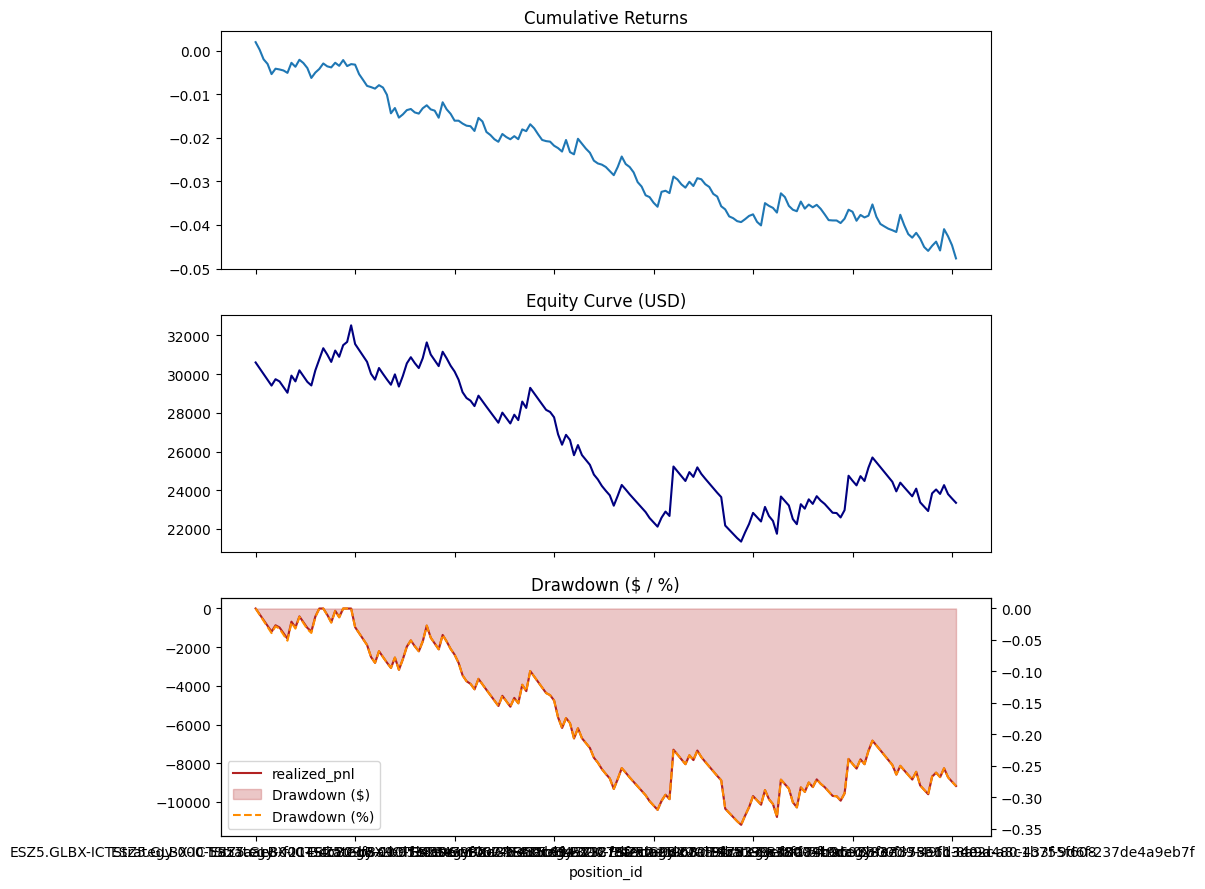

In [9]:
import matplotlib.pyplot as plt


def _money_to_float(series):
    # Convert object/str Money-like series to float values.
    if series.empty:
        return series
    if series.dtype != "O":
        return series
    cleaned = series.astype(str).str.replace(",", "")
    numeric = cleaned.str.split().str[0]
    return pd.to_numeric(numeric, errors="coerce")


positions_report = backtest_engine.trader.generate_positions_report()

if len(positions_report) == 0:
    print("No positions to report.")
else:
    # Cumulative profit in instrument currency
    returns_series = _money_to_float(positions_report["realized_return"])
    returns = returns_series.cumsum()

    # Build equity curve in USD (use realized_pnl if available, otherwise returns)
    starting_balance = 30_000
    if "realized_pnl" in positions_report.columns:
        pnl_series = _money_to_float(positions_report["realized_pnl"])
        equity = pnl_series.cumsum() + starting_balance
    else:
        equity = returns + starting_balance

    peak = equity.cummax()
    drawdown = equity - peak
    drawdown_pct = equity / peak - 1

    print(f"Max drawdown ($): {drawdown.min():,.2f}")
    print(f"Max drawdown (%): {drawdown_pct.min():.2%}")

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    returns.plot(ax=axes[0], title="Cumulative Returns")
    equity.plot(ax=axes[1], color="navy", title="Equity Curve (USD)")

    drawdown.plot(ax=axes[2], color="firebrick", title="Drawdown ($ / %)")
    axes[2].fill_between(drawdown.index, drawdown, 0, color="firebrick", alpha=0.25, label="Drawdown ($)")

    # Twin axis for percentage drawdown overlay
    ax_dd_pct = axes[2].twinx()
    drawdown_pct.plot(ax=ax_dd_pct, color="darkorange", linestyle="--", label="Drawdown (%)")

    # Combine legends for both axes
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax_dd_pct.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc="lower left")

    plt.tight_layout()
    plt.show()
